In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

import pandas as pd

from Functions import *

### Plotting Indicators

In [2]:
def plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol: str, period=14):

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2]})

    # Prepare data for candlestick
    quotes = []
    for idx, (multi_idx, row) in enumerate(df.iterrows()):
        timestamp = multi_idx
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Candlestick chart
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # MFI chart
    dates = [multi_idx for multi_idx in df_with_mfi.index]
    ax2.plot(dates, df_with_mfi['mfi'], color='purple', linewidth=1.5)
    # Overbought 
    ax2.axhline(y=80, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='g', linestyle='--', alpha=0.5)

    # Oversold
    ax2.fill_between(dates, df_with_mfi['mfi'], 80, where=(df_with_mfi['mfi'] >= 80), color='r', alpha=0.3)
    ax2.fill_between(dates, df_with_mfi['mfi'], 20, where=(df_with_mfi['mfi'] <= 20), color='g', alpha=0.3)

    ax2.set_ylabel('MFI')
    ax2.set_ylim(0, 100)
    ax2.grid(True)

    # Plot RSI
    dates = [multi_idx for multi_idx in df_with_rsi.index]
    ax3.plot(dates, df_with_rsi['rsi'], color='blue', linewidth=1.5)
    ax3.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
    ax3.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
    
    # Highlight overbought/oversold regions
    ax3.fill_between(dates, df_with_rsi['rsi'], 70, where=(df_with_rsi['rsi'] >= 70), 
                    color='r', alpha=0.3)  # Highlight overbought
    ax3.fill_between(dates, df_with_rsi['rsi'], 30, where=(df_with_rsi['rsi'] <= 30), 
                    color='g', alpha=0.3)  # Highlight oversold
    
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.grid(True)

    # Format x-axis with dates
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


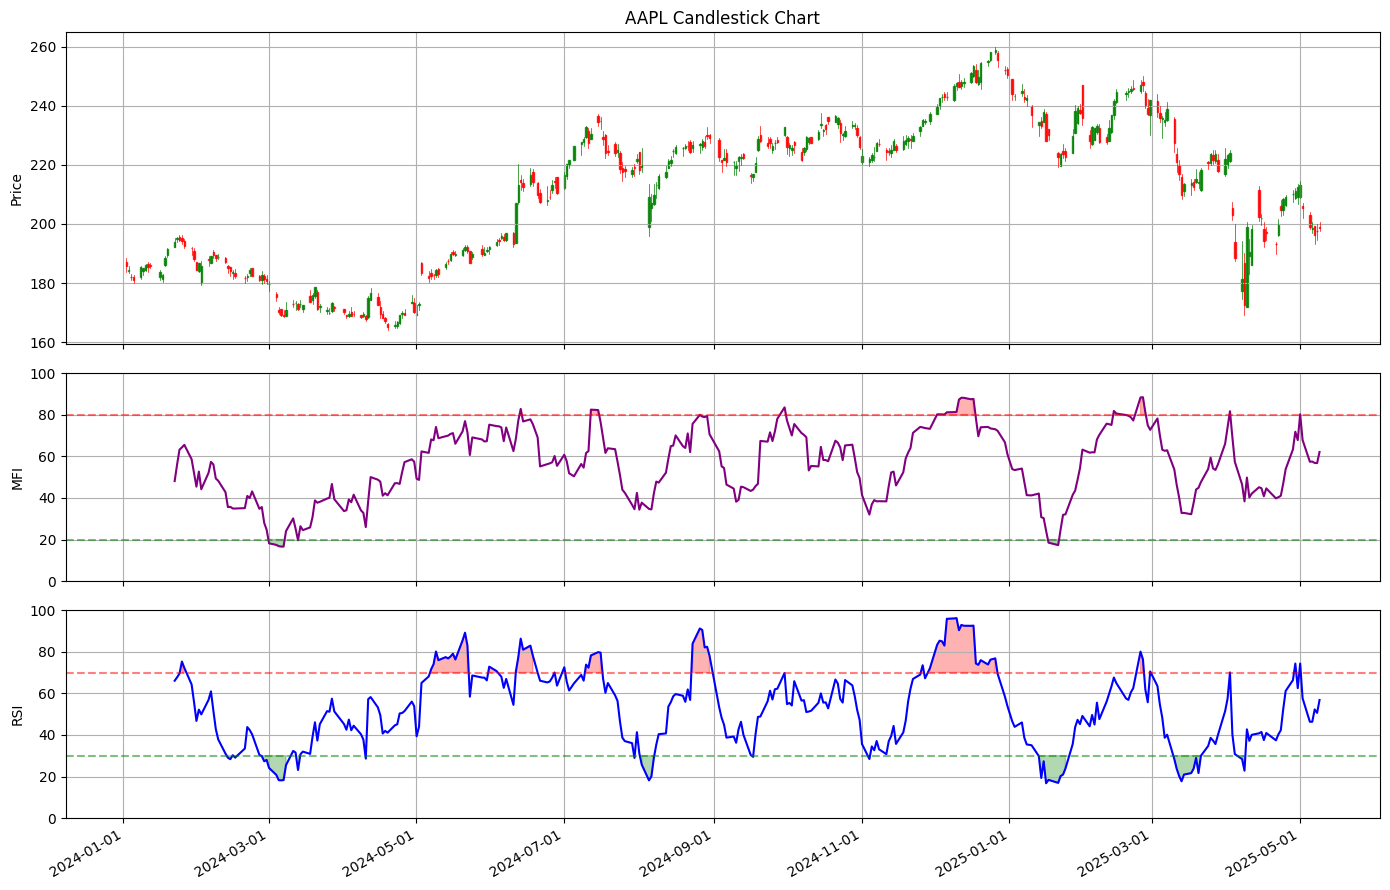

In [3]:
# Example usage
symbol = "AAPL"
start_date = "2024-01-1"
end_date = "2025-05-12"
timeframe_unit = "Day"  # "Day", "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# Calculate MFI
df_with_mfi = calculate_mfi(df)

# Calculate RSI
df_with_rsi = calculate_rsi(df)

# Plot candlestick chart with volume
plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol)

### Plotting Equity

In [4]:
def plot_equity_curve(equity_rsi, equity_mfi, equity_combined):
    plt.figure(figsize=(15, 6))
    plt.plot(equity_rsi, label='Equity Curve', linewidth=2)
    plt.title("RSI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_mfi, label='Equity Curve', linewidth=2)
    plt.title("MFI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_combined, label='Equity Curve', linewidth=2)
    plt.title("COMBINED Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

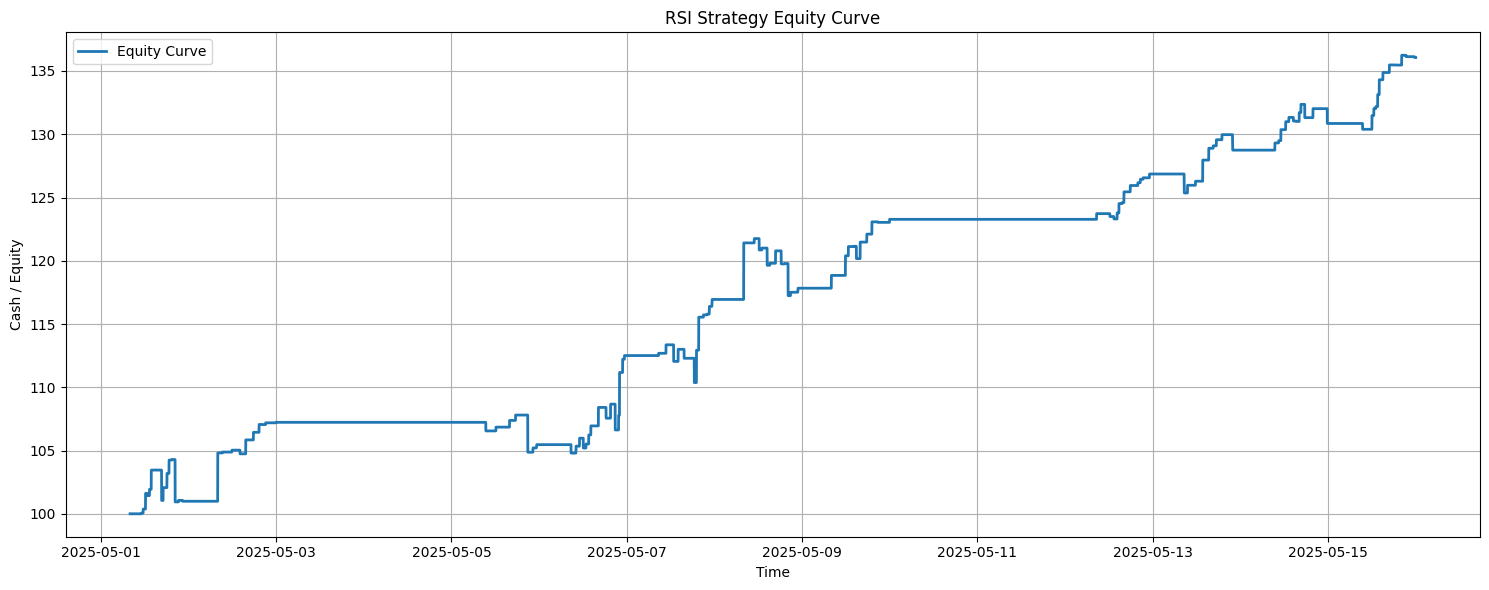

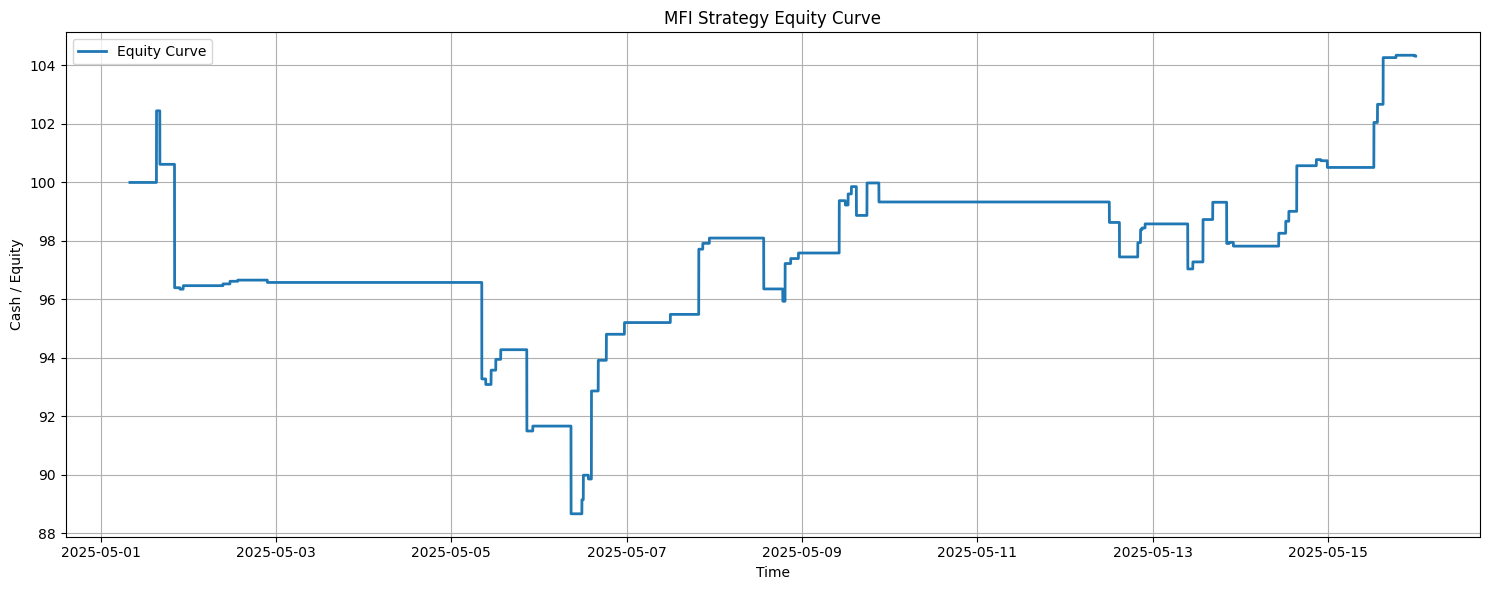

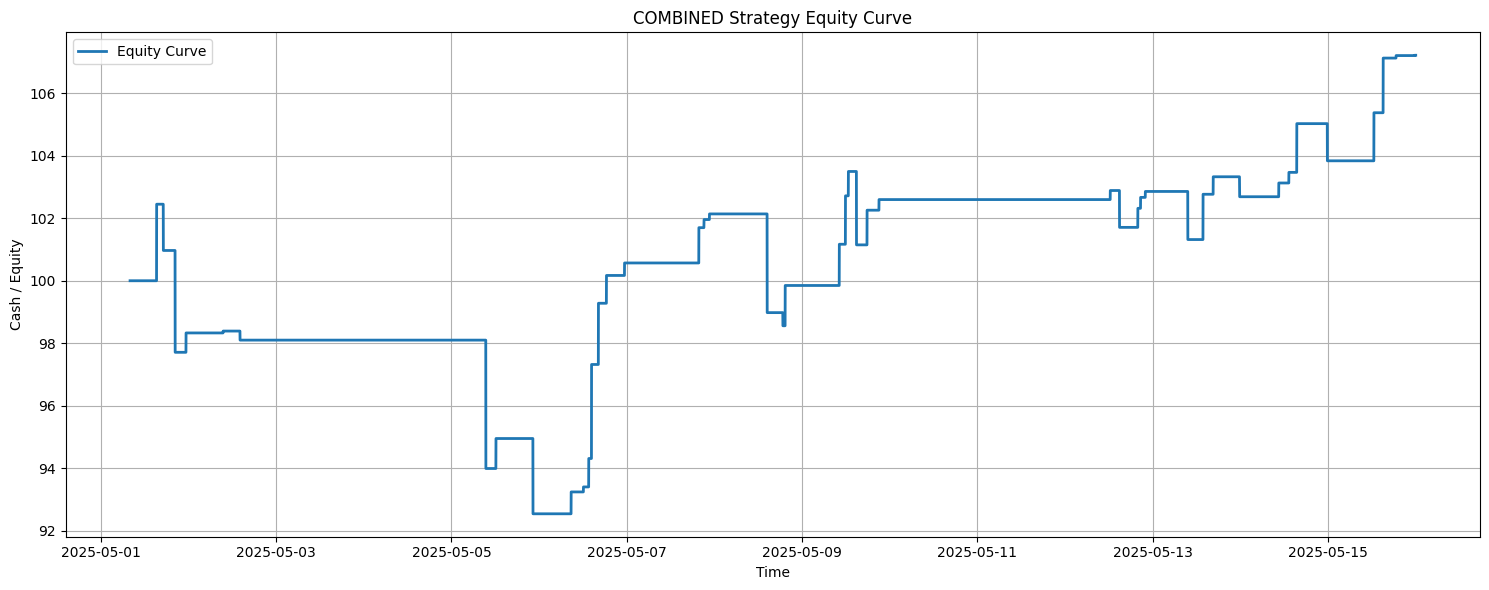

{'Number of Trades': 125, 'Win Rate (%)': 73.6, 'Avg PnL': np.float64(0.29), 'Best Trade': np.float64(4.47), 'Worst Trade': np.float64(-3.35), 'Avg Win': np.float64(0.73), 'Avg Loss': np.float64(-0.95), 'Reward:Risk Ratio': np.float64(0.77), 'Avg Duration (min)': np.float64(54.84), 'Win Std Dev': np.float64(0.77), 'Loss Std Dev': np.float64(0.9), 'Expectancy': np.float64(0.29)}
{'Number of Trades': 66, 'Win Rate (%)': 65.15, 'Avg PnL': np.float64(0.07), 'Best Trade': np.float64(3.01), 'Worst Trade': np.float64(-4.22), 'Avg Win': np.float64(0.68), 'Avg Loss': np.float64(-1.13), 'Reward:Risk Ratio': np.float64(0.6), 'Avg Duration (min)': np.float64(145.35), 'Win Std Dev': np.float64(0.72), 'Loss Std Dev': np.float64(1.23), 'Expectancy': np.float64(0.05)}
{'Number of Trades': 46, 'Win Rate (%)': 71.74, 'Avg PnL': np.float64(0.16), 'Best Trade': np.float64(3.01), 'Worst Trade': np.float64(-4.11), 'Avg Win': np.float64(0.89), 'Avg Loss': np.float64(-1.84), 'Reward:Risk Ratio': np.float64(0.

In [5]:
df = get_stock_data("SPY", "2025-05-01", "2025-05-16", "Minute", 1)

# RSI
signals = generate_signals_rsi(df)
equity_rsi, trade_log_rsi = backtest(signals)

# MFI
signals = generate_signals_mfi(df)
equity_mfi, trade_log_mfi = backtest(signals)

# Combined
signals = generate_combined_signal(df)
equity_combined, trade_log_combined = backtest(signals)

plot_equity_curve(equity_rsi, equity_mfi, equity_combined)
print(evaluate_trades(trade_log_rsi))
print(evaluate_trades(trade_log_mfi))
print(evaluate_trades(trade_log_combined))

TO DO:
Formal regression model

### High/Low Swept

##### Extra Functions

In [6]:
def get_session_high_low(df, session_start, session_end):
    session_data = df.between_time(session_start, session_end)
    high = session_data['high'].max()
    low = session_data['low'].min()
    return high, low

def is_sweep(current_price, previous_high, previous_low):
    return current_price > previous_high or current_price < previous_low

asian_high, asian_low = get_session_high_low(df, "20:00", "04:00")
london_high, london_low = get_session_high_low(df, "04:00", "09:30")
nyc_high, nyc_low = get_session_high_low(df, "09:30", "13:00")


def detect_bos(df):
    bos_points = []
    for i in range(2, len(df)):
        prev = df.iloc[i - 1]
        curr = df.iloc[i]
        if curr['high'] > prev['high'] and curr['low'] > prev['low']:
            bos_points.append((df.index[i], 'bullish'))
        elif curr['low'] < prev['low'] and curr['high'] < prev['high']:
            bos_points.append((df.index[i], 'bearish'))
    return bos_points

def get_fib_retrace_entry(df, leg_start_time, leg_end_time):
    leg_df = df.loc[leg_start_time:leg_end_time]
    high = leg_df['high'].max()
    low = leg_df['low'].min()
    fib_50 = (high + low) / 2
    for i in range(len(df)):
        if abs(df['close'].iloc[i] - fib_50) / fib_50 < 0.001:  # within 0.1%
            return df.index[i]
    return None


##### Highs/Lows confluence

In [7]:
def generate_sweep_signals(df, session_start="00:00", session_end="23:59"):
    """
    Sweep strategy:
    - If previous session high is swept, go SHORT.
    - If previous session low is swept, go LONG.
    Works on 15-minute data.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)  # Ensure datetime index
    df['signal'] = 0

    previous_high = None
    previous_low = None
    last_session_date = None

    for i in range(1, len(df)):
        current_time = df.index[i]
        current_date = current_time.date()

        if i == 1:
            last_session_date = current_date
            continue

        # Start new session if the day changes
        if last_session_date != current_date:
            # Define session boundaries for the previous day
            prev_day_data = df.loc[str(current_date - pd.Timedelta(days=1))]
            if not prev_day_data.empty:
                session_data = prev_day_data.between_time(session_start, session_end)
                if not session_data.empty:
                    previous_high = session_data['high'].max()
                    previous_low = session_data['low'].min()

            last_session_date = current_date

        # Entry logic — once a sweep occurs
        if previous_high and df['high'].iloc[i] > previous_high:
            df.iloc[i, df.columns.get_loc('signal')] = -1  # short signal
            previous_high = None  # avoid double counting
        elif previous_low and df['low'].iloc[i] < previous_low:
            df.iloc[i, df.columns.get_loc('signal')] = 1  # long signal
            previous_low = None

    return df[['close', 'signal']]


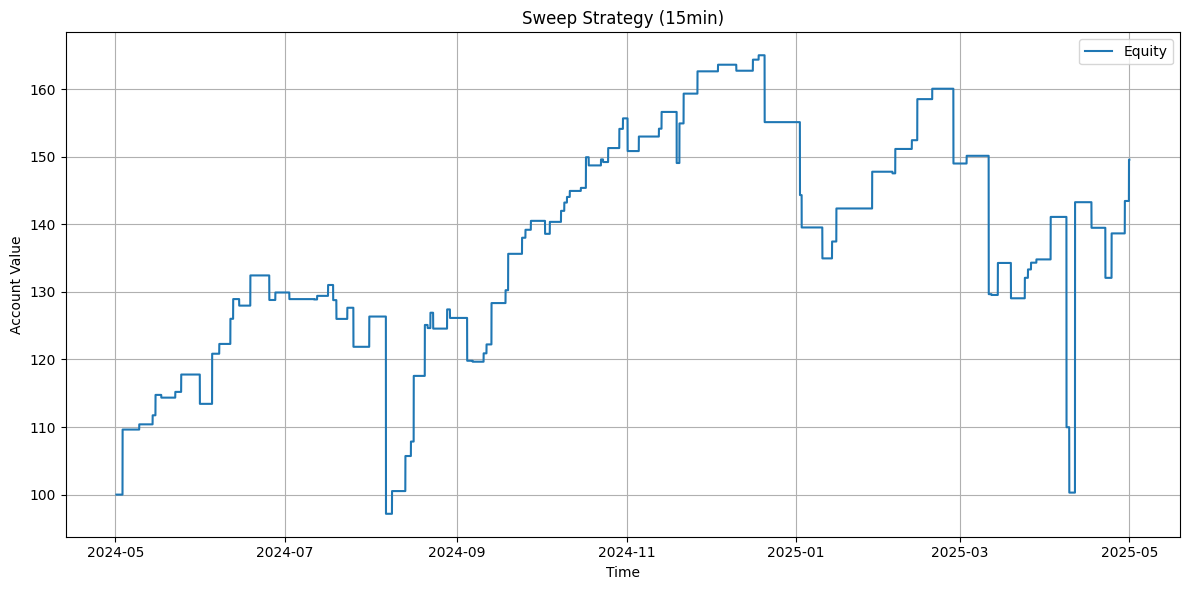

{'Number of Trades': 103, 'Win Rate (%)': 66.99, 'Avg PnL': np.float64(0.48), 'Best Trade': np.float64(42.99), 'Worst Trade': np.float64(-31.13), 'Avg Win': np.float64(3.57), 'Avg Loss': np.float64(-5.79), 'Reward:Risk Ratio': np.float64(0.62), 'Avg Duration (min)': np.float64(2350.92), 'Win Std Dev': np.float64(5.3), 'Loss Std Dev': np.float64(7.56), 'Expectancy': np.float64(0.48)}


In [8]:
# Load 15min data
df_15m = get_stock_data("SPY", "2024-05-01", "2025-05-01", timeframe_unit="Minute", multiplier=15)

# Generate sweep signals (use Asian session as example)
signal_df = generate_sweep_signals(df_15m, session_start="20:00", session_end="04:00")

# Backtest
equity_curve, trade_log = backtest(signal_df)

# Plot
def plot_equity_curve(equity_curve, title="Equity Curve"):
    plt.figure(figsize=(12, 6))
    plt.plot(equity_curve.index, equity_curve.values, label="Equity")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Account Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_equity_curve(equity_curve, title="Sweep Strategy (15min)")
print(evaluate_trades(trade_log))
